In [1]:
import plotly.express as px

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
from dash import Dash, dcc, html, Input, Output, callback

In [4]:
# dashboard initialization
app = Dash()

In [5]:
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_dash.csv"
df = pd.read_csv(url)

In [6]:
df.head(5)

,Unnamed: 0,Flight Number,Launch Site,class,Payload Mass (kg),Booster Version,Booster Version Category
0,0,1,CCAFS LC-40,0,0.0,F9 v1.0 B0003,v1.0
1,1,2,CCAFS LC-40,0,0.0,F9 v1.0 B0004,v1.0
2,2,3,CCAFS LC-40,0,525.0,F9 v1.0 B0005,v1.0
3,3,4,CCAFS LC-40,0,500.0,F9 v1.0 B0006,v1.0
4,4,5,CCAFS LC-40,0,677.0,F9 v1.0 B0007,v1.0


In [7]:
launch_sites = df[['Launch Site', 'class']].groupby(['Launch Site']).mean().reset_index()
launch_sites

,Launch Site,class
0,CCAFS LC-40,0.269231
1,CCAFS SLC-40,0.428571
2,KSC LC-39A,0.769231
3,VAFB SLC-4E,0.400000


In [8]:
arr = list(launch_sites['Launch Site'].values)
arr.insert(0, 'All Sites')
arr

['All Sites', 'CCAFS LC-40', 'CCAFS SLC-40', 'KSC LC-39A', 'VAFB SLC-4E']

In [9]:
# We want to have a dataframe with % of total success by launch sites(in order to render a pie chart of it later on)
# Let's group by launch Site calculating sum of successful launches
# Update by dividing each sum by the total sum of all successful launches
new_arr = df[['Launch Site', 'class']].groupby(['Launch Site']).sum().reset_index()
summ = int(new_arr[['class']].sum().iloc[0])


def percentage_calculation(num):
    return float(num) / summ


new_arr['class'] = new_arr['class'].apply(percentage_calculation)
new_arr

,Launch Site,class
0,CCAFS LC-40,0.291667
1,CCAFS SLC-40,0.125000
2,KSC LC-39A,0.416667
3,VAFB SLC-4E,0.166667


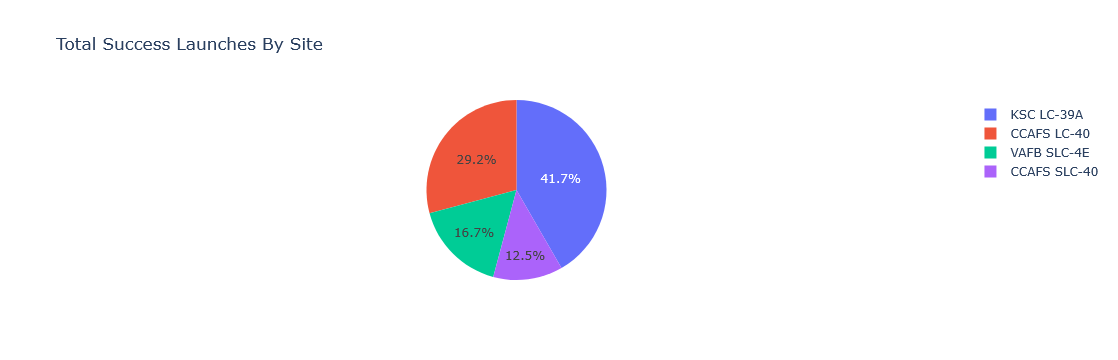

In [10]:
# Testing that this plotly express actually creates a graph we want
fig = px.pie(new_arr, values='class', names='Launch Site', title='Total Success Launches By Site')
fig

In [11]:
sites_new = df[['Launch Site', 'class']].groupby('Launch Site').mean()
smth = 'KSC LC-39A'
sites_new.loc[smth]

class    0.769231
Name: KSC LC-39A, dtype: float64

 VAFB SLC-4E


0.4 <class 'numpy.float64'>


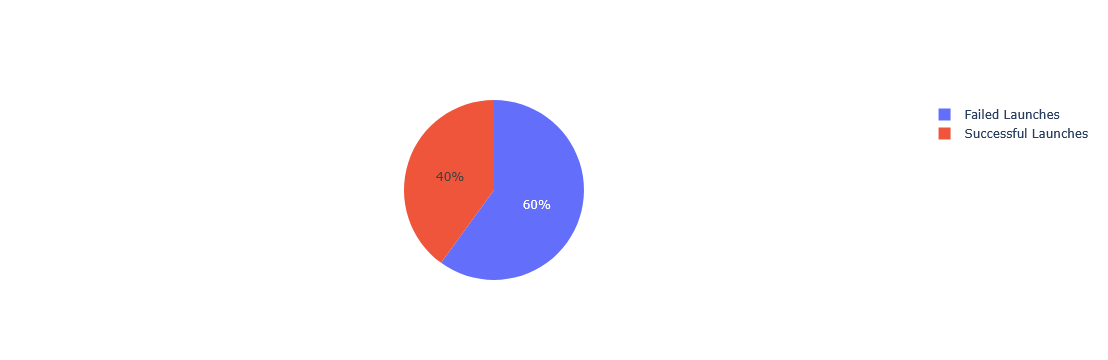

In [12]:
# Testing whether this diplays a required pie chart for each Launch Site
import plotly.graph_objects as go
import plotly.express as px

entered_site = str(input())
success_rate = sites_new.loc[entered_site, 'class']
print(success_rate, type(success_rate))
labels = ['Successful Launches', 'Failed Launches']
values = [success_rate, 1 - success_rate]

fig = go.Figure(data=[go.Pie(labels=labels, values=values)])
fig.show()

In [13]:
import plotly.graph_objects as go
import plotly.express as px

In [14]:
df.head()
payload_max = df['Payload Mass (kg)'].max()
payload_min = df['Payload Mass (kg)'].min()

In [15]:
'''    html.Br(),
    html.Div([
        dcc.RangeSlider(id='payload-slider',
                        min=0,
                        max=10000,
                        step = 1000,
                        value= [payload_min, payload_max]
                       )
    '''
#    Input('payload-slider', 'value')

"    html.Br(),\n    html.Div([\n        dcc.RangeSlider(id='payload-slider',\n                        min=0,\n                        max=10000,\n                        step = 1000,\n                        value= [payload_min, payload_max]\n                       )\n    "

In [35]:
app = Dash()

app.layout = html.Div([
    html.H4("SpaceX Launch Records Dashboard"),
    html.Div([
        dcc.Dropdown(options = arr, value = 'All Sites', id='site-dropdown')
    ]),
    html.Br(),
    html.Div([
        dcc.Graph(id='success-pie-chart')
    ], style={'display': 'flex'}),
    html.Br(),
    html.Div([
        dcc.RangeSlider(id='payload-slider',
                       min=0,
                       max=10000,
                       step=1000,
                       value=[payload_min, payload_max])
    ]),
    html.Br(),
    html.Div([
        dcc.Graph(id='success-payload-scatter-chart')
        ],
        style={'display':'flex'})
])
# Should change the last .Div to a graph

@app.callback(
    Output(component_id='success-pie-chart', component_property='figure'),
    Input('site-dropdown', 'value'),
    Input('payload-slider', 'value')
)
def get_pie_chart(entered_site, payload_range):
    filtered_df = new_arr
    if entered_site == 'All Sites':
        # This means that we want to see % of successful launches out of all successes for each launch site simultaneously
        fig = px.pie(filtered_df, values='class', names='Launch Site', title='Total Success Launches By Site')
    else:
        # This means that we want to see success % for a specific launch site
        success_rate = sites_new.loc[entered_site, 'class']
        labels = ['Successful Launches', 'Failed Launches']
        values = [success_rate, 1 - success_rate]
        fig = go.Figure(data=go.Pie(labels=labels, values=values))
    return fig


@app.callback(
    Output('success-payload-scatter-chart', 'figure'),
    Input('site-dropdown', 'value'),
    Input('payload-slider', 'value')
)
def get_scatterplot(entered_site, payload_range):
    if entered_site == 'All Sites':
        new_df = df[(df['Payload Mass (kg)'] <= payload_range[1]) & (df['Payload Mass (kg)'] >= payload_range[0])]
    else:
        new_df = df[(df['Launch Site'] == entered_site) & (df['Payload Mass (kg)'] <= payload_range[1]) & (df['Payload Mass (kg)'] >= payload_range[0])]
    fig = px.scatter(new_df, x='Payload Mass (kg)', y='class', color='Booster Version Category', width=1350, height=600, title='Success of Launch by Payload Mass, with Booster Version indication')
    return fig


if __name__ == '__main__':
    app.run(jupyter_mode='external')

Dash app running on http://127.0.0.1:8050/
